longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


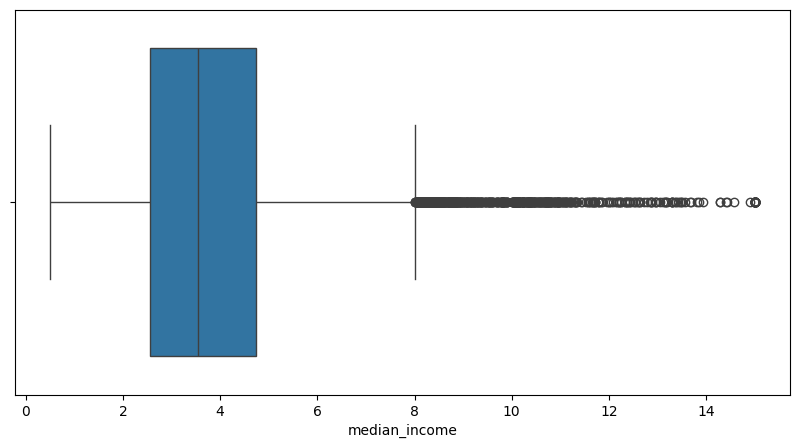

In [21]:
 #import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/housing.csv")

# Check missing values
print(df.isnull().sum())

# Fill missing values
median_value = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_value)

# Outlier visualization
plt.figure(figsize=(10,5))
sns.boxplot(x=df['median_income'])
plt.show()

# Remove outliers
Q1 = df['median_income'].quantile(0.25)
Q3 = df['median_income'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['median_income'] >= lower) &
    (df['median_income'] <= upper)
]

# Save cleaned dataset
df.to_csv("../data/cleaned_housing.csv", index=False)
